In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def generate_data(n=5000):
    data = []

    for _ in range(n):
        # Generate different patterns for each class
        rand = np.random.random()
        
        if rand < 0.33:  # Safe class (33%)
            mq2 = np.random.randint(0, 300)
            temp = np.random.uniform(20, 40)
            flame = 0
            label = 0
            
        elif rand < 0.66:  # Alert class (33%)
            mq2 = np.random.randint(300, 800)
            temp = np.random.uniform(40, 70)
            flame = np.random.randint(0, 1)
            label = 1
            
        else:  # Hazardous class (34%)
            mq2 = np.random.randint(800, 1200)
            temp = np.random.uniform(60, 100)
            flame = 1
            label = 2

        # Add some noise for better generalization
        mq2 = int(np.clip(mq2 + np.random.normal(0, 50), 0, 1200))
        temp = np.clip(temp + np.random.normal(0, 5), 0, 120)

        data.append([mq2, temp, flame, label])

    return pd.DataFrame(data, columns=["mq2", "temp", "flame", "label"])


# Generate balanced dataset
df = generate_data(6000)
df.to_csv("fire_dataset.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df["label"].value_counts().sort_index())
print(f"\nDataset head:")
print(df.head(10))

# Prepare features and labels
X = df.drop("label", axis=1).values
y = df["label"].values

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Dataset shape: (6000, 4)

Class distribution:
label
0    1956
1    2009
2    2035
Name: count, dtype: int64

Dataset head:
   mq2       temp  flame  label
0  671  53.691618      0      1
1  944  68.249683      1      2
2  315  54.783055      0      1
3   84  31.458718      0      0
4   45  26.025085      0      0
5   79  41.580011      0      0
6  904  77.528977      1      2
7  200  20.663830      0      0
8  884  64.098140      1      2
9  441  55.537848      0      1

Training set size: (4800, 3)
Test set size: (1200, 3)
Training class distribution: [1561 1611 1628]
Test class distribution: [395 398 407]


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Build GRU model using TensorFlow/Keras
model = keras.Sequential([
    layers.GRU(64, input_shape=(1, 3), return_sequences=False, dropout=0.3),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

# Hyperparameters
input_size = 3   # mq2, temp, flame
hidden_size = 64
num_classes = 3
learning_rate = 0.001
num_epochs = 100
batch_size = 32
dropout = 0.3

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, weight_decay=1e-5)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model initialized successfully!")
print(f"Total parameters: {model.count_params()}")
print(f"\nModel architecture:")
model.summary()

Model initialized successfully!
Total parameters: 17603

Model architecture:


d:\Rising India Hackathon\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,603 (68.76 KB)

 Trainable params: 17,603 (68.76 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Reshape data for GRU (add sequence dimension)
X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"X_train shape: {X_train_reshaped.shape}")
print(f"X_test shape: {X_test_reshaped.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = keras.callbacks.ModelCheckpoint(
    'models/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Learning rate reduction
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Train the model
print("\nStarting training...\n")
history = model.fit(
    X_train_reshaped, y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(X_test_reshaped, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

X_train shape: (4800, 1, 3)
X_test shape: (1200, 1, 3)
y_train shape: (4800,)
y_test shape: (1200,)

Starting training...

Epoch 1/100
139/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7543 - loss: 0.6778
Epoch 1: val_accuracy improved from None to 0.97500, saving model to models/best_model.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.4689 - val_accuracy: 0.9750 - val_loss: 0.1185 - learning_rate: 0.0010
Epoch 2/100
111/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8889 - loss: 0.2938
Epoch 2: val_accuracy did not improve from 0.97500
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.2934 - val_accuracy: 0.9675 - val_loss: 0.1057 - learning_rate: 0.0010
Epoch 3/100
 97/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8867 - loss: 0.2843
Epoch 3: val_accuracy improved from 0.97500 to 0.98917, saving model to models/best_model.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8965 - loss: 0.2684 - val_accuracy: 0.9892 - val_loss: 0.0797 - learning_rate: 0.0010
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8897 - loss: 0.2837
Epoch 4: val_accuracy did not improve from 0.98917
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8933 - loss: 0.2776 - val_accuracy: 0.9775 - val_loss: 0.0944 - learning_rate: 0.0010
Epoch 5/100
101/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9039 - loss: 0.2524
Epoch 5: val_accuracy did not improve from 0.98917
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9046 - loss: 0.2511 - val_accuracy: 0.9858 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 6/100
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8995 - loss: 0.2726
Epoch 6: val_accuracy did not improve from 0.98917
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8954 - loss: 0.2707 - val_accuracy: 0.9858 - val_loss: 0.0880 - learning_rate: 0.0010
Epoch 7/100
145/150 ━━

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8965 - loss: 0.2724 - val_accuracy: 0.9900 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 9/100
142/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8917 - loss: 0.2716
Epoch 9: val_accuracy improved from 0.99000 to 0.99333, saving model to models/best_model.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8965 - loss: 0.2642 - val_accuracy: 0.9933 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 10/100
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9035 - loss: 0.2458
Epoch 10: val_accuracy did not improve from 0.99333
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9025 - loss: 0.2560 - val_accuracy: 0.9892 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 11/100
108/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8972 - loss: 0.2670
Epoch 11: val_accuracy did not improve from 0.99333
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8981 - loss: 0.2626 - val_accuracy: 0.9917 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 12/100
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9076 - loss: 0.2433
Epoch 12: val_accuracy did not improve from 0.99333
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9021 - loss: 0.2518 - val_accuracy: 0.9933 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 13/100
106

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8973 - loss: 0.2593 - val_accuracy: 0.9942 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 15/100
103/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9039 - loss: 0.2420
Epoch 15: val_accuracy did not improve from 0.99417
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9015 - loss: 0.2481 - val_accuracy: 0.9833 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 16/100
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9111 - loss: 0.2456
Epoch 16: val_accuracy did not improve from 0.99417
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9100 - loss: 0.2454 - val_accuracy: 0.9917 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 17/100
147/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9026 - loss: 0.2528
Epoch 17: val_accuracy did not improve from 0.99417
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9038 - loss: 0.2482 - val_accuracy: 0.9925 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 18/100
129

Evaluating model on test set...

Test Loss: 0.0775
Test Accuracy: 0.9933

Classification Report:
              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99       395
       Alert       0.99      0.99      0.99       398
   Hazardous       1.00      1.00      1.00       407

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200


Confusion Matrix:
[[390   5   0]
 [  3 395   0]
 [  0   0 407]]

F1-Score per class: Safe=0.9898, Alert=0.9900, Hazardous=1.0000
Macro F1-Score: 0.9933
Weighted F1-Score: 0.9933


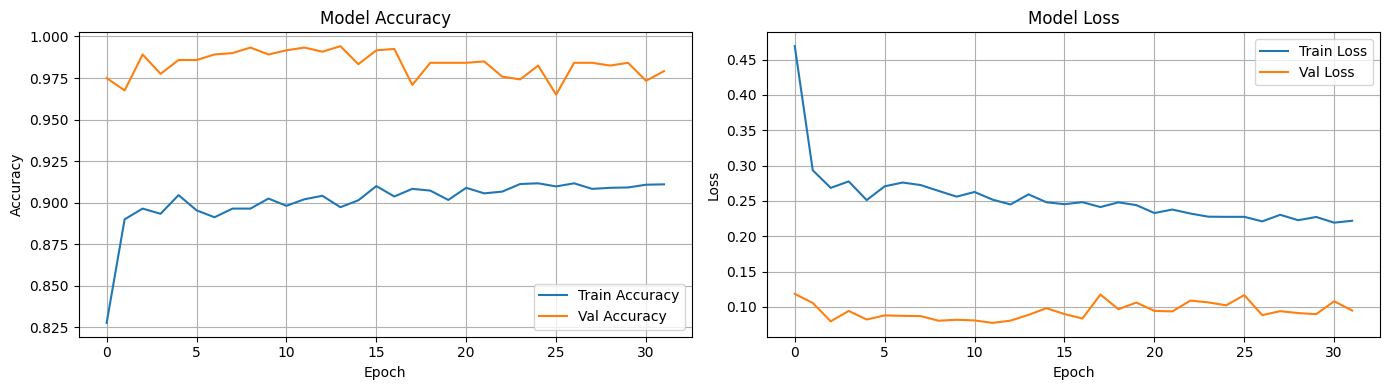


Training history plot saved!


In [4]:
# Evaluation on test set
print("Evaluating model on test set...\n")

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Get predictions
y_pred_probs = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Detailed metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe", "Alert", "Hazardous"]))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Per-class metrics
f1_per_class = f1_score(y_test, y_pred, average=None)
print(f"\nF1-Score per class: Safe={f1_per_class[0]:.4f}, Alert={f1_per_class[1]:.4f}, Hazardous={f1_per_class[2]:.4f}")
print(f"Macro F1-Score: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('models/training_history.png', dpi=100)
plt.show()

print("\nTraining history plot saved!")

In [5]:
import os
import json

# Create directory for models if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the final model in .keras format (modern TensorFlow format)
model_path = "models/gru_fire_detection_model.keras"
model.save(model_path)
print(f"Model saved (.keras): {model_path}")

# The best model is also saved as H5 via checkpoint during training
best_model_path = "models/best_model.h5"
if os.path.exists(best_model_path):
    print(f"Best model also available: {best_model_path}")
else:
    print("Note: Best model checkpoint will be saved during training")

# Save the scaler for inference
import pickle
scaler_path = "models/scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

# Save model configuration
model_config = {
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_classes": num_classes,
    "learning_rate": learning_rate,
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "dropout": dropout,
    "framework": "TensorFlow/Keras",
    "model_type": "GRU",
    "input_shape": [1, 3]
}

config_path = "models/model_config.json"
with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)
print(f"Config saved to: {config_path}")

# Save training results
results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "f1_scores": {
        "safe": float(f1_per_class[0]),
        "alert": float(f1_per_class[1]),
        "hazardous": float(f1_per_class[2]),
        "macro": float(f1_score(y_test, y_pred, average='macro')),
        "weighted": float(f1_score(y_test, y_pred, average='weighted'))
    },
    "confusion_matrix": cm.tolist(),
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "class_distribution_train": {
        "safe": int(np.bincount(y_train)[0]), 
        "alert": int(np.bincount(y_train)[1]), 
        "hazardous": int(np.bincount(y_train)[2])
    },
    "class_distribution_test": {
        "safe": int(np.bincount(y_test)[0]), 
        "alert": int(np.bincount(y_test)[1]), 
        "hazardous": int(np.bincount(y_test)[2])
    }
}

results_path = "models/training_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=4)
print(f"Training results saved to: {results_path}")

print("\n All models and configurations saved successfully!")
print(f" Files created in 'models/' directory:")
print(f"  - gru_fire_detection_model.keras (Final model)")
print(f"  - best_model.h5 (Best checkpoint)")
print(f"  - scaler.pkl (Feature normalizer)")
print(f"  - model_config.json (Configuration)")
print(f"  - training_results.json (Performance metrics)")
print(f"  - training_history.png (Learning curves)")

Model saved (.keras): models/gru_fire_detection_model.keras
Best model also available: models/best_model.h5
Scaler saved to: models/scaler.pkl
Config saved to: models/model_config.json
Training results saved to: models/training_results.json

 All models and configurations saved successfully!
 Files created in 'models/' directory:
  - gru_fire_detection_model.keras (Final model)
  - best_model.h5 (Best checkpoint)
  - scaler.pkl (Feature normalizer)
  - model_config.json (Configuration)
  - training_results.json (Performance metrics)
  - training_history.png (Learning curves)
